In [1]:
# ============================================================
# CELL 1: Environment Setup and Library Imports
# Purpose:
# Install and import all required libraries for data preprocessing,
# forecasting, drift detection, explainability, and visualization.
# ============================================================

!pip install keras-tcn -q
!pip install xgboost -q
!pip install statsmodels -q
!pip install shap -q
!pip install streamlit -q
!pip install holidays -q

import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_theme(style="whitegrid", context="talk")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.seasonal import STL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tcn import TCN

from xgboost import XGBRegressor
import shap
import holidays

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.5 MB/s eta 0:00:00
Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2: Central Project Configuration
# Purpose:
# Change important project settings from one place.
# ============================================================

CONFIG = {
    "n_files": 50,
    "n_households": 500,
    "min_days_per_household": 180,
    "val_days": 30,
    "test_days": 60,
    "lookback": 30,
    "stl_period": 7,
    "max_compare_houses": 10,
    "selected_household": "MAC000006",   # change anytime
    "output_dir": "outputs_global",
    "streamlit_dir": "streamlit_app",
    "event_quantile": 0.95,
    "consecutive_days": 3,
    "xgb_param_grid": {
        "n_estimators": [200, 400],
        "max_depth": [4, 6],
        "learning_rate": [0.03, 0.05],
        "subsample": [0.8],
        "colsample_bytree": [0.8]
    },
    "rf_param_grid": {
        "n_estimators": [200, 400],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 3],
        "max_features": ["sqrt"]
    },
    "cv_splits": 3
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["streamlit_dir"], exist_ok=True)

print(CONFIG)

{'n_files': 50, 'n_households': 100, 'min_days_per_household': 180, 'val_days': 30, 'test_days': 60, 'lookback': 30, 'stl_period': 7, 'max_compare_houses': 10, 'selected_household': 'MAC000006', 'output_dir': 'outputs_global', 'streamlit_dir': 'streamlit_app', 'event_quantile': 0.95, 'consecutive_days': 3, 'xgb_param_grid': {'n_estimators': [200, 400], 'max_depth': [4, 6], 'learning_rate': [0.03, 0.05], 'subsample': [0.8], 'colsample_bytree': [0.8]}, 'rf_param_grid': {'n_estimators': [200, 400], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 3], 'max_features': ['sqrt']}, 'cv_splits': 3}


In [3]:
# ============================================================
# CELL 3: Data Access and File Paths
# Purpose:
# Mount Google Drive and define file paths for all datasets.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

energy_glob = "/content/drive/MyDrive/Energy/LCL-June2015v2_*.csv"
tg_path = "/content/drive/MyDrive/Weather/TG_STAID001860.txt"
tx_path = "/content/drive/MyDrive/Weather/TX_STAID001860.txt"
tn_path = "/content/drive/MyDrive/Weather/TN_STAID001860.txt"
carbon_path = "/content/drive/MyDrive/Carbon Intensity Dataset.csv"


Mounted at /content/drive


In [4]:
# ============================================================
# CELL 4: Load and Sort Energy Data Files
# ============================================================

def extract_number(filename: str) -> int:
    match = re.search(r'_(\d+)\.csv$', filename)
    return int(match.group(1)) if match else -1

energy_files = glob.glob(energy_glob)
energy_files_sorted = sorted(energy_files, key=extract_number)

print("Total energy files found:", len(energy_files_sorted))
print("Example files:", energy_files_sorted[:3])


Total energy files found: 168
Example files: ['/content/drive/MyDrive/Energy/LCL-June2015v2_0.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_1.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_2.csv']


In [5]:
# ============================================================
# CELL 5: Load and Combine Energy Data
# ============================================================

files_to_use = energy_files_sorted[:CONFIG["n_files"]]
print("Number of selected files:", len(files_to_use))

energy_parts = []
for fp in files_to_use:
    temp_df = pd.read_csv(fp, low_memory=False)
    temp_df["source_file"] = os.path.basename(fp)
    energy_parts.append(temp_df)

energy_raw = pd.concat(energy_parts, ignore_index=True)
energy_raw.columns = energy_raw.columns.str.strip().str.lower()

print("Combined shape:", energy_raw.shape)
energy_raw.head()


Number of selected files: 50
Combined shape: (50000000, 5)


,lclid,stdortou,datetime,kwh/hh (per half hour),source_file
0,MAC000002,Std,2012-10-12 00:30:00.0000000,0,LCL-June2015v2_0.csv
1,MAC000002,Std,2012-10-12 01:00:00.0000000,0,LCL-June2015v2_0.csv
2,MAC000002,Std,2012-10-12 01:30:00.0000000,0,LCL-June2015v2_0.csv
3,MAC000002,Std,2012-10-12 02:00:00.0000000,0,LCL-June2015v2_0.csv
4,MAC000002,Std,2012-10-12 02:30:00.0000000,0,LCL-June2015v2_0.csv


In [6]:
# ============================================================
# CELL 6: Clean Energy Data
# ============================================================

energy_raw = energy_raw.rename(columns={
    "lclid": "LCLid",
    "stdortou": "stdorToU",
    "kwh/hh (per half hour)": "kwh_hh"
})

energy_raw["datetime"] = pd.to_datetime(energy_raw["datetime"], errors="coerce")
energy_raw["kwh_hh"] = pd.to_numeric(energy_raw["kwh_hh"], errors="coerce")

energy_raw = energy_raw.dropna(subset=["LCLid", "datetime", "kwh_hh"])
energy_raw["date"] = energy_raw["datetime"].dt.normalize()

print("Cleaned shape:", energy_raw.shape)
print(energy_raw.isna().sum())
energy_raw.head()


Cleaned shape: (49998412, 6)
LCLid          0
stdorToU       0
datetime       0
kwh_hh         0
source_file    0
date           0
dtype: int64


,LCLid,stdorToU,datetime,kwh_hh,source_file,date
0,MAC000002,Std,2012-10-12 00:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
1,MAC000002,Std,2012-10-12 01:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
2,MAC000002,Std,2012-10-12 01:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
3,MAC000002,Std,2012-10-12 02:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
4,MAC000002,Std,2012-10-12 02:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12


In [9]:
# ============================================================
# CELL 7: Daily Aggregation
# ============================================================

energy_daily = (
    energy_raw.groupby(["LCLid", "date"], as_index=False)["kwh_hh"]
    .sum()
    .rename(columns={"kwh_hh": "daily_kWh"})
)

energy_daily["daily_kWh_log"] = np.log1p(energy_daily["daily_kWh"])

print("Daily shape:", energy_daily.shape)
print("Households:", energy_daily["LCLid"].nunique())
print("Date range:", energy_daily["date"].min(), "to", energy_daily["date"].max())
energy_daily.head()

Daily shape: (1045743, 4)
Households: 1587
Date range: 2011-11-23 00:00:00 to 2014-02-28 00:00:00


,LCLid,date,daily_kWh,daily_kWh_log
0,MAC000002,2012-10-12,7.098,2.092
1,MAC000002,2012-10-13,11.087,2.492
2,MAC000002,2012-10-14,13.223,2.655
3,MAC000002,2012-10-15,10.257,2.421
4,MAC000002,2012-10-16,9.769,2.377


In [10]:
# ============================================================
# CELL 8: Household Coverage Summary
# ============================================================

df_cov = energy_daily.copy().sort_values(["LCLid", "date"]).reset_index(drop=True)

coverage = df_cov.groupby("LCLid").agg(
    start=("date", "min"),
    end=("date", "max"),
    n_days=("date", "count"),
    mean_kwh=("daily_kWh", "mean"),
    median_kwh=("daily_kWh", "median"),
    std_kwh=("daily_kWh", "std")
).reset_index()

coverage["span_days"] = (coverage["end"] - coverage["start"]).dt.days + 1
coverage["missing_days_est"] = coverage["span_days"] - coverage["n_days"]
coverage = coverage.sort_values("n_days", ascending=False)

coverage.head()

,LCLid,start,end,n_days,mean_kwh,median_kwh,std_kwh,span_days,missing_days_est
124,MAC000151,2011-11-23,2014-02-28,829,3.741,3.735,0.698,829,0
130,MAC000157,2011-11-23,2014-02-28,829,11.524,11.088,2.692,829,0
126,MAC000153,2011-11-23,2014-02-28,829,30.751,29.100,11.946,829,0
125,MAC000152,2011-11-23,2014-02-28,829,9.306,8.898,4.713,829,0
123,MAC000150,2011-11-23,2014-02-28,829,9.751,8.783,4.021,829,0


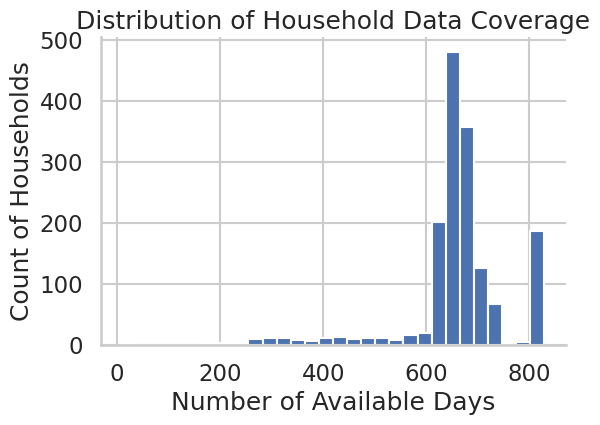

In [11]:
plt.figure(figsize=(6, 4))
plt.hist(coverage["n_days"], bins=30)
plt.title("Distribution of Household Data Coverage")
plt.xlabel("Number of Available Days")
plt.ylabel("Count of Households")
plt.show()

In [12]:
# ============================================================
# CELL 9: Load Weather Data
# ============================================================

def load_ecad(path: str, value_col: str, q_col: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=20)
    df.columns = ["SOUID", "DATE", value_col, q_col]
    df["date"] = pd.to_datetime(df["DATE"], format="%Y%m%d", errors="coerce")
    return df[["date", value_col]]

tg = load_ecad(tg_path, "TG", "Q_TG")
tx = load_ecad(tx_path, "TX", "Q_TX")
tn = load_ecad(tn_path, "TN", "Q_TN")

tg["temp_mean"] = tg["TG"] / 10
tx["temp_max"] = tx["TX"] / 10
tn["temp_min"] = tn["TN"] / 10

weather = (
    tg[["date", "temp_mean"]]
    .merge(tx[["date", "temp_max"]], on="date", how="inner")
    .merge(tn[["date", "temp_min"]], on="date", how="inner")
)

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (17166, 4)


,date,temp_mean,temp_max,temp_min
0,1979-01-02,-2.600,1.600,-7.500
1,1979-01-03,-2.800,1.300,-7.200
2,1979-01-04,-2.600,-0.300,-6.500
3,1979-01-05,-0.800,5.600,-1.400
4,1979-01-06,-0.500,8.300,-6.600


In [13]:
# ============================================================
# CELL 10: Load Carbon Intensity Data
# ============================================================

carbon_raw = pd.read_csv(carbon_path)
carbon_raw["DATETIME"] = pd.to_datetime(carbon_raw["DATETIME"], errors="coerce")
carbon_raw["date"] = carbon_raw["DATETIME"].dt.normalize()

carbon_daily = (
    carbon_raw.groupby("date", as_index=False)["CARBON_INTENSITY"]
    .mean()
    .rename(columns={"CARBON_INTENSITY": "carbon_intensity"})
)

print("Carbon daily shape:", carbon_daily.shape)
carbon_daily.head()


Carbon daily shape: (6263, 2)


,date,carbon_intensity
0,2009-01-01,541.688
1,2009-01-02,571.938
2,2009-01-03,566.750
3,2009-01-04,565.938
4,2009-01-05,586.042


In [14]:
# ============================================================
# CELL 11: Merge Energy, Weather, and Carbon Data
# ============================================================

start_date = energy_daily["date"].min()
end_date = energy_daily["date"].max()

weather_f = weather[(weather["date"] >= start_date) & (weather["date"] <= end_date)].copy()
carbon_f = carbon_daily[(carbon_daily["date"] >= start_date) & (carbon_daily["date"] <= end_date)].copy()

merged = energy_daily.merge(weather_f, on="date", how="left")
merged2 = merged.merge(carbon_f, on="date", how="left")

print("Merged shape:", merged2.shape)
print("Missing values:")
print(merged2[["temp_mean", "temp_max", "temp_min", "carbon_intensity"]].isna().sum())
merged2.head()


Merged shape: (1045743, 8)
Missing values:
temp_mean           0
temp_max            0
temp_min            0
carbon_intensity    0
dtype: int64


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity
0,MAC000002,2012-10-12,7.098,2.092,12.300,13.500,9.700,527.625
1,MAC000002,2012-10-13,11.087,2.492,9.600,12.900,5.600,556.479
2,MAC000002,2012-10-14,13.223,2.655,7.400,14.200,1.900,547.667
3,MAC000002,2012-10-15,10.257,2.421,8.600,15.900,2.900,549.333
4,MAC000002,2012-10-16,9.769,2.377,12.100,17.500,8.300,540.667


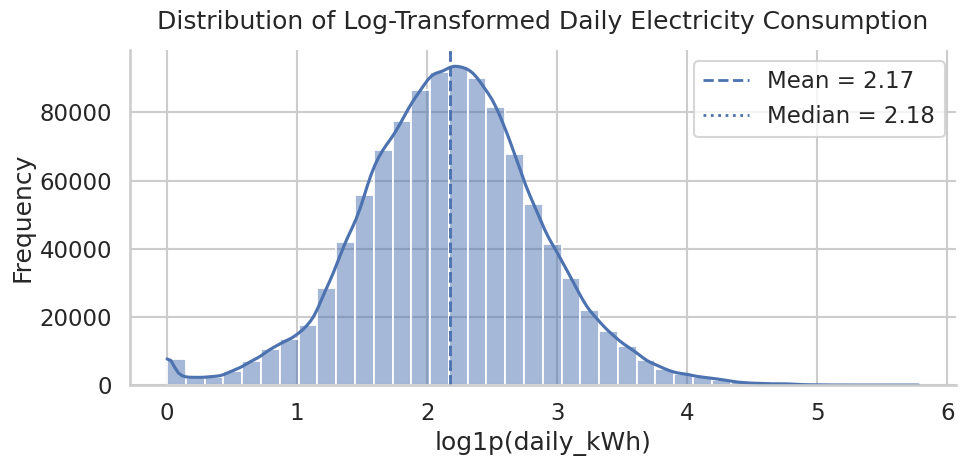

In [15]:
# ============================================================
# CELL 12.1: Distribution of Log Consumption
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=merged2, x="daily_kWh_log", bins=40, kde=True, ax=ax)

mean_val = merged2["daily_kWh_log"].mean()
median_val = merged2["daily_kWh_log"].median()

ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")

ax.set_title("Distribution of Log-Transformed Daily Electricity Consumption", pad=15)
ax.set_xlabel("log1p(daily_kWh)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


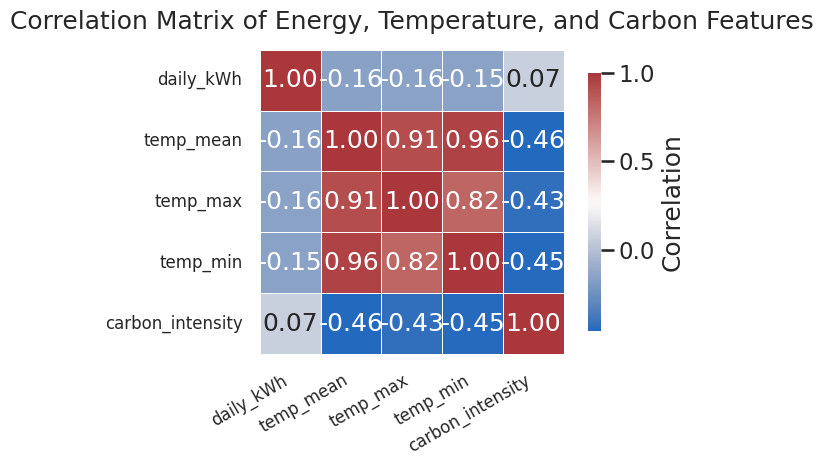

In [16]:
# ============================================================
# CELL 12.2: Correlation Matrix
# ============================================================
corr = merged2[["daily_kWh", "temp_mean", "temp_max", "temp_min", "carbon_intensity"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="vlag", fmt=".2f", linewidths=0.7, square=True,
            cbar_kws={"shrink": 0.85, "label": "Correlation"})
plt.title("Correlation Matrix of Energy, Temperature, and Carbon Features", pad=15)
plt.xticks(fontsize=12, rotation=30, ha="right")
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

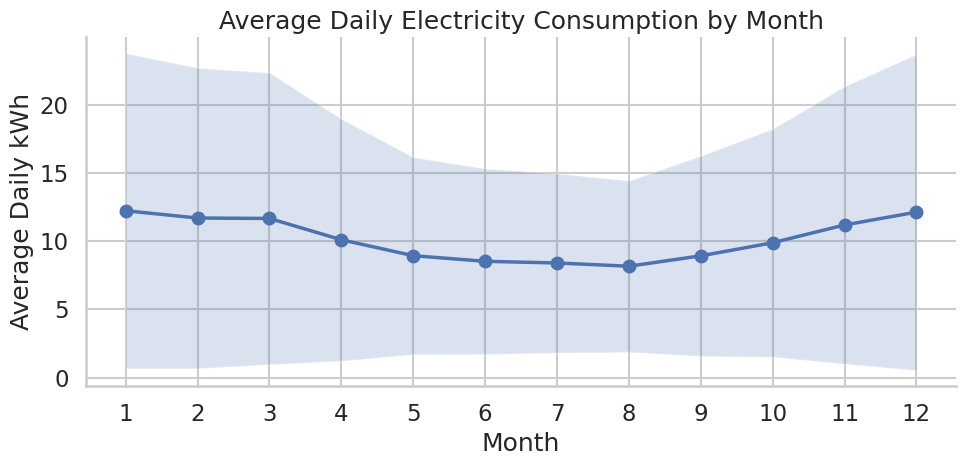

In [17]:
# ============================================================
# CELL 12.3: Monthly Seasonality
# ============================================================

monthly_stats = merged2.groupby(merged2["date"].dt.month)["daily_kWh"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats["date"], monthly_stats["mean"], marker="o", linewidth=2.5)
plt.fill_between(monthly_stats["date"], monthly_stats["mean"] - monthly_stats["std"],
                 monthly_stats["mean"] + monthly_stats["std"], alpha=0.2)
plt.title("Average Daily Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily kWh")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Outlier rows: 61407
Outlier percentage: 5.87 %


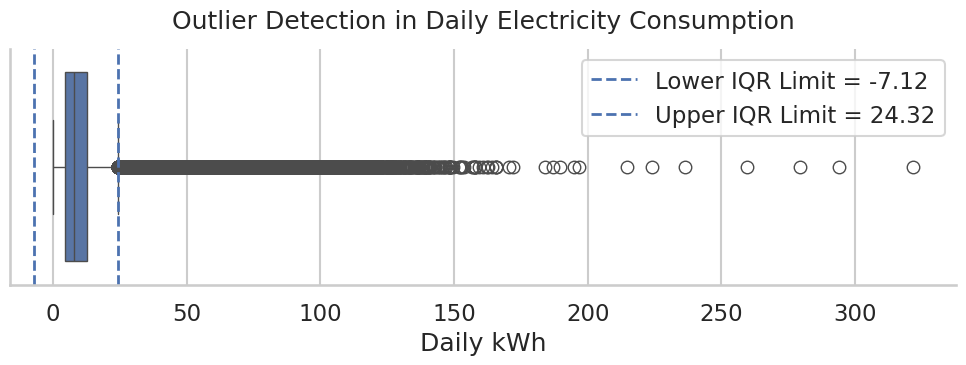

In [20]:
# ============================================================
# CELL 12.4: Outlier Detection
# ============================================================

Q1 = merged2["daily_kWh"].quantile(0.25)
Q3 = merged2["daily_kWh"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged2[(merged2["daily_kWh"] < lower) | (merged2["daily_kWh"] > upper)]

print("Outlier rows:", len(outliers))
print("Outlier percentage:", round(100 * len(outliers) / len(merged2), 2), "%")

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=merged2["daily_kWh"], ax=ax)
ax.axvline(lower, linestyle="--", linewidth=2, label=f"Lower IQR Limit = {lower:.2f}")
ax.axvline(upper, linestyle="--", linewidth=2, label=f"Upper IQR Limit = {upper:.2f}")
ax.set_title("Outlier Detection in Daily Electricity Consumption", pad=15)
ax.set_xlabel("Daily kWh")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

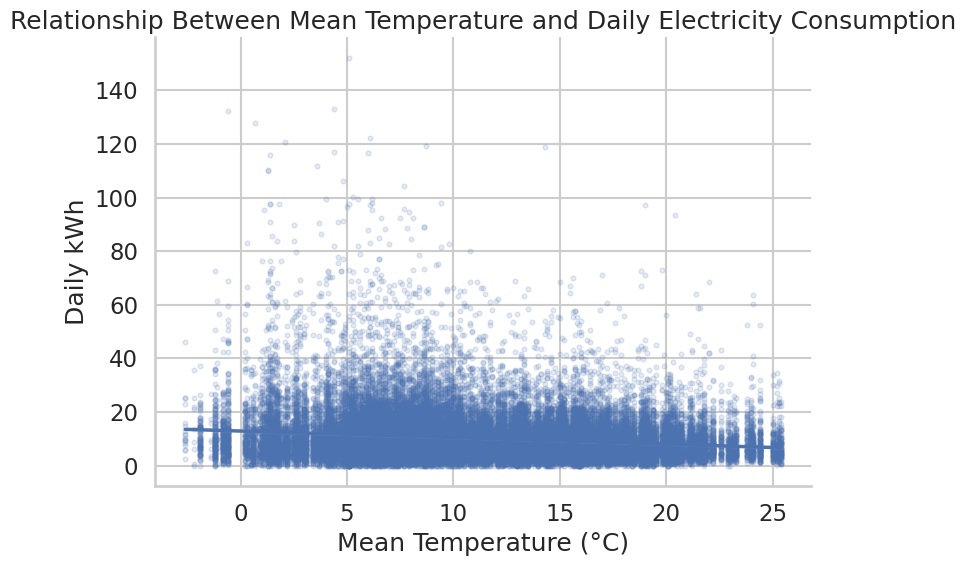

In [21]:
# ============================================================
# CELL 12.5: Temperature vs Energy
# ============================================================

sample_df = merged2.sample(min(50000, len(merged2)), random_state=42)

plt.figure(figsize=(8, 6))
sns.regplot(data=sample_df, x="temp_mean", y="daily_kWh",
            scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"linewidth": 2.5})
plt.title("Relationship Between Mean Temperature and Daily Electricity Consumption")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")
plt.tight_layout()
plt.show()

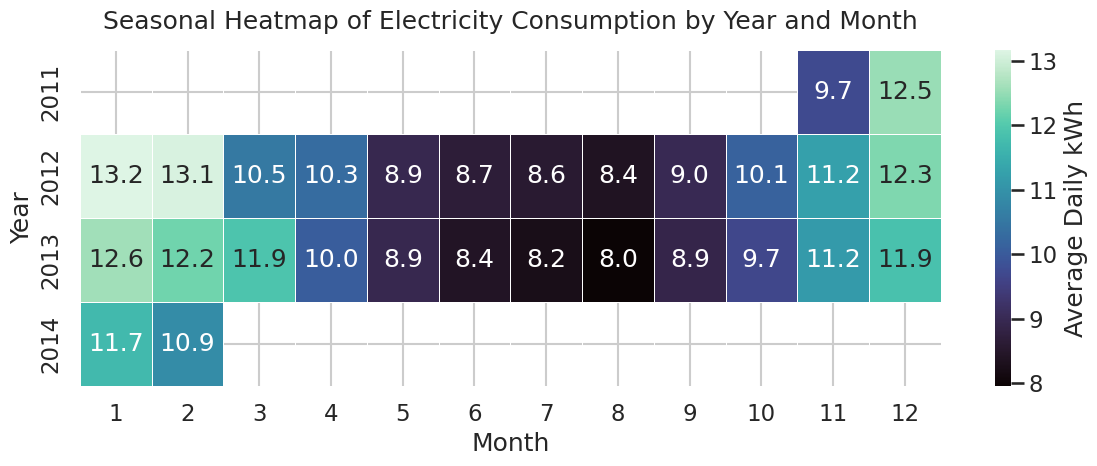

In [22]:
# ============================================================
# CELL 12.6: Seasonal Heatmap
# ============================================================

season_df = merged2.copy()
season_df["year"] = season_df["date"].dt.year
season_df["month"] = season_df["date"].dt.month
season_pivot = season_df.groupby(["year", "month"])["daily_kWh"].mean().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(season_pivot, cmap="mako", annot=True, fmt=".1f", linewidths=0.5,
            cbar_kws={"label": "Average Daily kWh"})
plt.title("Seasonal Heatmap of Electricity Consumption by Year and Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# CELL 12.7: Missingness Check
# ============================================================

missing_summary = merged2.isna().mean().sort_values(ascending=False) * 100
missing_summary

,0
LCLid,0.000
date,0.000
daily_kWh,0.000
daily_kWh_log,0.000
temp_mean,0.000
temp_max,0.000
temp_min,0.000
carbon_intensity,0.000


In [24]:
# ============================================================
# CELL 13: Feature Engineering for Time-Series Modelling
# ============================================================

df = merged2.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["LCLid", "date"]).reset_index(drop=True)

# Calendar features
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# UK holiday features
uk_holidays = holidays.country_holidays("GB", subdiv="ENG")
df["date_only"] = df["date"].dt.date
df["is_holiday"] = df["date_only"].apply(lambda d: int(d in uk_holidays))
df["is_day_before_holiday"] = df["date_only"].apply(lambda d: int((pd.Timestamp(d) + pd.Timedelta(days=1)).date() in uk_holidays))
df["is_day_after_holiday"] = df["date_only"].apply(lambda d: int((pd.Timestamp(d) - pd.Timedelta(days=1)).date() in uk_holidays))

# Cyclical encoding
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Weather/context
df["HDD_18"] = np.maximum(0, 18 - df["temp_mean"])
df["temp_range"] = df["temp_max"] - df["temp_min"]
df["is_winter"] = df["month"].isin([12, 1, 2]).astype(int)
df["is_summer"] = df["month"].isin([6, 7, 8]).astype(int)

# Lag features
lag_days = [1, 2, 3, 7, 14, 30]
for L in lag_days:
    df[f"lag_{L}"] = df.groupby("LCLid")["daily_kWh"].shift(L)

# Rolling features without leakage
g = df.groupby("LCLid")["daily_kWh"]
roll_windows = [7, 14, 30]
for w in roll_windows:
    shifted = g.shift(1)
    df[f"roll_mean_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).mean()
    df[f"roll_std_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).std()
    df[f"roll_min_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).min()
    df[f"roll_max_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).max()

needed = [f"lag_{L}" for L in lag_days] + [f"roll_mean_{w}" for w in roll_windows]
df_model = df.dropna(subset=needed + ["temp_mean", "carbon_intensity"]).copy()

df_model = df_model.drop(columns=["date_only"])

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (998187, 42)


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,day_of_week,month,year,day_of_month,is_weekend,is_holiday,is_day_before_holiday,is_day_after_holiday,dow_sin,dow_cos,month_sin,month_cos,HDD_18,temp_range,is_winter,is_summer,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,roll_mean_7,roll_std_7,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30
30,MAC000002,2012-11-11,10.699,2.460,6.000,12.700,1.300,541.438,6,11,2012,11,1,0,0,0,-0.782,0.623,-0.500,0.866,12.000,11.400,0,0,13.245,16.722,0.186,14.507,19.629,7.098,12.079,5.487,0.186,16.722,13.561,4.431,0.186,19.629,13.447,4.395,0.186,24.490
31,MAC000002,2012-11-12,12.321,2.589,8.000,15.500,3.200,535.438,0,11,2012,12,0,0,0,0,0.000,1.000,-0.500,0.866,10.000,12.300,0,0,10.699,13.245,16.722,15.095,12.779,11.087,11.535,5.394,0.186,16.722,12.923,4.122,0.186,17.822,13.567,4.263,0.186,24.490
32,MAC000002,2012-11-13,10.264,2.422,11.400,14.200,7.300,525.167,1,11,2012,13,0,0,0,0,0.782,0.623,-0.500,0.866,6.600,6.900,0,0,12.321,10.699,13.245,11.663,13.961,13.223,11.139,5.187,0.186,16.722,12.891,4.125,0.186,17.822,13.608,4.244,0.186,24.490
33,MAC000002,2012-11-14,10.820,2.470,12.000,10.100,9.700,563.188,2,11,2012,14,0,0,0,0,0.975,-0.223,-0.500,0.866,6.000,0.400,0,0,10.264,12.321,10.699,13.137,17.822,10.257,10.939,5.190,0.186,16.722,12.626,4.169,0.186,17.822,13.510,4.288,0.186,24.490
34,MAC000002,2012-11-15,9.808,2.380,7.100,12.600,4.000,581.688,3,11,2012,15,0,0,0,0,0.434,-0.901,-0.500,0.866,10.900,8.600,0,0,10.820,10.264,12.321,0.186,12.209,9.769,10.608,5.100,0.186,16.722,12.126,3.910,0.186,16.722,13.528,4.274,0.186,24.490


In [25]:
# ============================================================
# CELL 14: Global Household Selection and Split
# ============================================================

df_model["date"] = pd.to_datetime(df_model["date"])
merged2["date"] = pd.to_datetime(merged2["date"])

coverage2 = df_model.groupby("LCLid").agg(
    n_days=("date", "count"),
    start=("date", "min"),
    end=("date", "max")
).reset_index()

eligible_households = coverage2.loc[
    coverage2["n_days"] >= CONFIG["min_days_per_household"], "LCLid"
].tolist()

selected_households = eligible_households[:CONFIG["n_households"]]

print("Eligible households:", len(eligible_households))
print("Selected households:", len(selected_households))
print("Example households:", selected_households[:10])

df_model_sel = df_model[df_model["LCLid"].isin(selected_households)].copy()
merged2_sel = merged2[merged2["LCLid"].isin(selected_households)].copy()

max_date = df_model_sel["date"].max()
test_start = max_date - pd.Timedelta(days=CONFIG["test_days"] - 1)
val_start = test_start - pd.Timedelta(days=CONFIG["val_days"])

train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[(df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

print("Validation starts:", val_start)
print("Test starts:", test_start)
print("Max date:", max_date)
print("Train shape:", train_global.shape)
print("Validation shape:", val_global.shape)
print("Test shape:", test_global.shape)

Eligible households: 1581
Selected households: 100
Example households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012']
Validation starts: 2013-12-01 00:00:00
Test starts: 2013-12-31 00:00:00
Max date: 2014-02-28 00:00:00
Train shape: (65352, 42)
Validation shape: (2700, 42)
Test shape: (5384, 42)


In [26]:
# ============================================================
# CELL 14.1: Split Verification
# ============================================================

print("Train rows incorrectly inside validation/test:", (train_global["date"] >= val_start).sum())
print("Validation rows outside validation window:", ((val_global["date"] < val_start) | (val_global["date"] >= test_start)).sum())
print("Test rows incorrectly before test start:", (test_global["date"] < test_start).sum())

split_check = df_model_sel.groupby("LCLid").apply(
    lambda x: pd.Series({
        "train_rows": (x["date"] < val_start).sum(),
        "val_rows": ((x["date"] >= val_start) & (x["date"] < test_start)).sum(),
        "test_rows": (x["date"] >= test_start).sum()
    })
).reset_index()

print(split_check.head())
print("Households with zero validation rows:", (split_check["val_rows"] == 0).sum())
print("Households with zero test rows:", (split_check["test_rows"] == 0).sum())

Train rows incorrectly inside validation/test: 0
Validation rows outside validation window: 0
Test rows incorrectly before test start: 0
       LCLid  train_rows  val_rows  test_rows
0  MAC000002         385        30         60
1  MAC000003         620        30         60
2  MAC000004         542        30         60
3  MAC000006         641        30         60
4  MAC000007         403        30         60
Households with zero validation rows: 10
Households with zero test rows: 10


In [27]:
# ============================================================
# CELL 15: Manual Household Selection for Detailed Analysis
# ============================================================

SELECTED_HOUSE = CONFIG["selected_household"]
if SELECTED_HOUSE not in selected_households:
    SELECTED_HOUSE = selected_households[0]

print("Selected household:", SELECTED_HOUSE)

Selected household: MAC000006


In [28]:
# ============================================================
# CELL 16: CUSUM Drift Function
# ============================================================

def cusum_drift(residuals, baseline_residuals=None, k_mult=0.5, h_mult=5.0):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if baseline_residuals is None:
        baseline_residuals = residuals

    baseline_residuals = np.asarray(baseline_residuals, dtype=float)
    baseline_residuals = np.nan_to_num(baseline_residuals, nan=0.0)

    mu0 = np.mean(baseline_residuals)
    sigma0 = np.std(baseline_residuals)

    if sigma0 == 0 or np.isnan(sigma0):
        n = len(residuals)
        return np.zeros(n), np.zeros(n), np.zeros(n, dtype=bool), 0.0, 0.0, mu0, sigma0

    k = k_mult * sigma0
    h = h_mult * sigma0

    s_pos = np.zeros(len(residuals))
    s_neg = np.zeros(len(residuals))

    for i in range(1, len(residuals)):
        x = residuals[i] - mu0
        s_pos[i] = max(0, s_pos[i-1] + x - k)
        s_neg[i] = min(0, s_neg[i-1] + x + k)

    alerts = (s_pos > h) | (s_neg < -h)
    return s_pos, s_neg, alerts, k, h, mu0, sigma0

In [29]:
# ============================================================
# CELL 16.1: EWMA Drift Function
# ============================================================

def ewma_drift(residuals, baseline_residuals=None, alpha=0.3, L=3):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if len(residuals) == 0:
        return np.array([]), np.array([], dtype=bool), np.nan, np.nan, np.nan, np.nan

    if baseline_residuals is None:
        baseline_residuals = residuals

    baseline_residuals = np.asarray(baseline_residuals, dtype=float)
    baseline_residuals = np.nan_to_num(baseline_residuals, nan=0.0)

    mu0 = np.mean(baseline_residuals)
    sigma0 = np.std(baseline_residuals)

    ewma = np.zeros(len(residuals))
    ewma[0] = residuals[0]

    for i in range(1, len(residuals)):
        ewma[i] = alpha * residuals[i] + (1 - alpha) * ewma[i-1]

    if sigma0 == 0 or np.isnan(sigma0):
        upper = mu0
        lower = mu0
        alerts = np.zeros(len(ewma), dtype=bool)
    else:
        sigma_ewma = sigma0 * np.sqrt(alpha / (2 - alpha))
        upper = mu0 + L * sigma_ewma
        lower = mu0 - L * sigma_ewma
        alerts = (ewma > upper) | (ewma < lower)

    return ewma, alerts, upper, lower, mu0, sigma0

In [30]:
# ============================================================
# CELL 16.2: STL Baseline
# ============================================================

def stl_baseline(df_home, period=7, min_days=60):
    x = df_home[["date", "daily_kWh"]].dropna().sort_values("date").copy()
    x = x.set_index("date").asfreq("D")
    x["daily_kWh"] = x["daily_kWh"].interpolate(limit=7)

    if x["daily_kWh"].dropna().shape[0] < min_days:
        return None

    stl = STL(x["daily_kWh"], period=period, robust=True)
    res = stl.fit()

    x["trend"] = res.trend
    x["seasonal"] = res.seasonal
    x["expected_kWh"] = x["trend"] + x["seasonal"]
    x["residual"] = x["daily_kWh"] - x["expected_kWh"]

    return x.reset_index()

In [31]:
# ============================================================
# CELL 16.3: Early Detection Evaluation
# ============================================================

def evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test",
                             baseline_residuals=None, consecutive_days=3, event_quantile=0.95):
    temp = home_test.copy()

    if temp.empty:
        return {
            "event_date": pd.NaT,
            "first_alert": pd.NaT,
            "lead_time_days": np.nan,
            "false_alarm_rate": np.nan,
            "stability_score": np.nan,
            "event_threshold": np.nan,
        }

    if baseline_residuals is None or len(baseline_residuals) == 0:
        baseline_residuals = temp[residual_col].dropna().values

    threshold = np.quantile(baseline_residuals, event_quantile) if len(baseline_residuals) > 0 else np.nan

    temp["event_flag"] = (temp[residual_col] > threshold).astype(int)
    temp["event_run"] = temp["event_flag"].rolling(consecutive_days).sum()

    event_date = temp.loc[temp["event_run"] >= consecutive_days, "date"].min()
    first_alert = temp.loc[temp[alert_col] == True, "date"].min()

    lead_time = (event_date - first_alert).days if pd.notna(event_date) and pd.notna(first_alert) else np.nan

    if pd.notna(event_date):
        false_alarms = temp[(temp[alert_col] == True) & (temp["date"] < event_date)]
        false_alarm_rate = len(false_alarms) / len(temp) if len(temp) > 0 else np.nan
    else:
        false_alarm_rate = temp[alert_col].sum() / len(temp) if len(temp) > 0 else np.nan

    stability_score = temp[alert_col].rolling(consecutive_days).sum().max()

    return {
        "event_date": event_date,
        "first_alert": first_alert,
        "lead_time_days": lead_time,
        "false_alarm_rate": false_alarm_rate,
        "stability_score": stability_score,
        "event_threshold": threshold,
    }

In [32]:
# ============================================================
# CELL 16.4: Regression Metrics
# ============================================================

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    r2 = r2_score(y_true, y_pred)

    return {"mae": mae, "rmse": rmse, "mape": mape, "smape": smape, "r2": r2}

In [39]:
# ============================================================
# CELL 16.5: Utility Functions
# ============================================================

def run_timeseries_cv_model(train_df, feature_cols, target_col, param_grid, model_type="xgb", n_splits=3):
    train_sorted = train_df.sort_values("date").reset_index(drop=True)
    X_cv = train_sorted[feature_cols]
    y_cv = train_sorted[target_col]
    tscv = TimeSeriesSplit(n_splits=n_splits)

    best_score = np.inf
    best_params = None
    cv_rows = []

    for params in ParameterGrid(param_grid):
        fold_maes = []
        for tr_idx, va_idx in tscv.split(X_cv):
            X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
            y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

            if model_type == "xgb":
                model = XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=-1, **params)
            elif model_type == "rf":
                model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
            else:
                raise ValueError("model_type must be 'xgb' or 'rf'")

            model.fit(X_tr, y_tr)
            pred_va = model.predict(X_va)
            fold_maes.append(mean_absolute_error(y_va, pred_va))

        avg_mae = float(np.mean(fold_maes))
        cv_rows.append({"model_type": model_type, "params": str(params), "cv_mae": avg_mae})

        if avg_mae < best_score:
            best_score = avg_mae
            best_params = params

    cv_results = pd.DataFrame(cv_rows).sort_values("cv_mae").reset_index(drop=True)
    return best_params, best_score, cv_results


def apply_drift_methods(df_res, residual_col, prefix, baseline_by_house=None):
    out = []
    for hid, g in df_res.groupby("LCLid"):
        g = g.sort_values("date").copy()
        baseline_residuals = None
        if baseline_by_house is not None and hid in baseline_by_house:
            baseline_residuals = baseline_by_house[hid]

        r = g[residual_col].fillna(0).values
        cusum_pos, cusum_neg, cusum_alert, k, h, _, _ = cusum_drift(r, baseline_residuals=baseline_residuals)
        ewma_vals, ewma_alert, ewma_upper, ewma_lower, _, _ = ewma_drift(r, baseline_residuals=baseline_residuals)

        g[f"{prefix}_cusum_pos"] = cusum_pos
        g[f"{prefix}_cusum_neg"] = cusum_neg
        g[f"{prefix}_cusum_alert"] = cusum_alert
        g[f"{prefix}_cusum_k"] = k
        g[f"{prefix}_cusum_h"] = h
        g[f"{prefix}_ewma"] = ewma_vals
        g[f"{prefix}_ewma_alert"] = ewma_alert
        g[f"{prefix}_ewma_upper"] = ewma_upper
        g[f"{prefix}_ewma_lower"] = ewma_lower
        out.append(g)

    return pd.concat(out, ignore_index=True)


def compute_forecast_metrics(df_pred, actual_col, pred_col, model_name):
    rows = []
    for hid, g in df_pred.groupby("LCLid"):
        m = regression_metrics(g[actual_col].values, g[pred_col].values)
        rows.append({"LCLid": hid, "model": model_name, **m})
    return pd.DataFrame(rows)


def evaluate_alerts(df_alerts, alert_col, residual_col, method_name, baseline_by_house=None):
    rows = []
    for hid, g in df_alerts.groupby("LCLid"):
        baseline_residuals = None
        if baseline_by_house is not None and hid in baseline_by_house:
            baseline_residuals = baseline_by_house[hid]
        ev = evaluate_early_detection(
            g.sort_values("date"),
            alert_col=alert_col,
            residual_col=residual_col,
            baseline_residuals=baseline_residuals,
            consecutive_days=CONFIG["consecutive_days"],
            event_quantile=CONFIG["event_quantile"]
        )
        rows.append({"LCLid": hid, "method": method_name, **ev})
    return pd.DataFrame(rows)


def carbon_impact_summary(df_res, residual_col, model_name):
    temp = df_res.copy()
    temp["positive_excess_kwh"] = temp[residual_col].clip(lower=0)
    temp["excess_carbon_g"] = temp["positive_excess_kwh"] * temp["carbon_intensity"]
    out = (
        temp.groupby("LCLid")
        .agg(excess_energy_kwh=("positive_excess_kwh", "sum"),
             excess_carbon_g=("excess_carbon_g", "sum"))
        .reset_index()
    )
    out["model"] = model_name
    return out

In [40]:
# ============================================================
# CELL 17: Encode Household ID and Define Feature Columns
# ============================================================

le_house = LabelEncoder()
df_model_sel["LCLid_code"] = le_house.fit_transform(df_model_sel["LCLid"])

train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[(df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

feature_cols = [c for c in df_model_sel.columns if c not in ["LCLid", "date", "daily_kWh", "daily_kWh_log"]]

X_train = train_global[feature_cols]
y_train = train_global["daily_kWh"]
X_val = val_global[feature_cols]
y_val = val_global["daily_kWh"]
X_test = test_global[feature_cols]
y_test = test_global["daily_kWh"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (65352, 39)
X_val: (2700, 39)
X_test: (5384, 39)


In [41]:
# ============================================================
# CELL 18: Global XGBoost with 3-Fold TimeSeries CV
# ============================================================

best_xgb_params, best_xgb_cv_mae, xgb_cv_results = run_timeseries_cv_model(
    train_df=train_global,
    feature_cols=feature_cols,
    target_col="daily_kWh",
    param_grid=CONFIG["xgb_param_grid"],
    model_type="xgb",
    n_splits=CONFIG["cv_splits"]
)

print("Best XGB params:", best_xgb_params)
print("Best XGB CV MAE:", best_xgb_cv_mae)

trainval_global = pd.concat([train_global, val_global], axis=0).sort_values(["date", "LCLid"]).reset_index(drop=True)
X_trainval = trainval_global[feature_cols]
y_trainval = trainval_global["daily_kWh"]

global_xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1,
    **best_xgb_params
)
global_xgb.fit(X_trainval, y_trainval)

test_global_xgb = test_global[["LCLid", "date", "daily_kWh", "carbon_intensity"]].copy()
test_global_xgb["xgb_pred"] = global_xgb.predict(X_test)
test_global_xgb["xgb_residual"] = test_global_xgb["daily_kWh"] - test_global_xgb["xgb_pred"]

# validation residuals per house for drift baseline
val_global_xgb = val_global[["LCLid", "date", "daily_kWh"]].copy()
val_global_xgb["xgb_pred"] = global_xgb.predict(X_val)
val_global_xgb["xgb_residual"] = val_global_xgb["daily_kWh"] - val_global_xgb["xgb_pred"]

xgb_baseline_by_house = {
    hid: g["xgb_residual"].dropna().values for hid, g in val_global_xgb.groupby("LCLid")
}

test_global_xgb = apply_drift_methods(test_global_xgb, "xgb_residual", "xgb", baseline_by_house=xgb_baseline_by_house)
xgb_metrics_all = compute_forecast_metrics(test_global_xgb, "daily_kWh", "xgb_pred", "XGBoost")
xgb_cusum_eval = evaluate_alerts(test_global_xgb, "xgb_cusum_alert", "xgb_residual", "XGB_CUSUM", baseline_by_house=xgb_baseline_by_house)
xgb_ewma_eval = evaluate_alerts(test_global_xgb, "xgb_ewma_alert", "xgb_residual", "XGB_EWMA", baseline_by_house=xgb_baseline_by_house)
carbon_xgb = carbon_impact_summary(test_global_xgb, "xgb_residual", "XGBoost")

Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best XGB CV MAE: 2.0204245023429332


In [43]:
# ============================================================
# CELL 19: Global Random Forest with 3-Fold TimeSeries CV
# ============================================================

best_rf_params, best_rf_cv_mae, rf_cv_results = run_timeseries_cv_model(
    train_df=train_global,
    feature_cols=feature_cols,
    target_col="daily_kWh",
    param_grid=CONFIG["rf_param_grid"],
    model_type="rf",
    n_splits=CONFIG["cv_splits"]
)

print("Best RF params:", best_rf_params)
print("Best RF CV MAE:", best_rf_cv_mae)

trainval_global = pd.concat([train_global, val_global], axis=0).sort_values(["date", "LCLid"]).reset_index(drop=True)
X_trainval = trainval_global[feature_cols]
y_trainval = trainval_global["daily_kWh"]

global_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_rf_params
)
global_rf.fit(X_trainval, y_trainval)

test_global_rf = test_global[["LCLid", "date", "daily_kWh", "carbon_intensity"]].copy()
test_global_rf["rf_pred"] = global_rf.predict(X_test)
test_global_rf["rf_residual"] = test_global_rf["daily_kWh"] - test_global_rf["rf_pred"]

# validation residuals per house for drift baseline
val_global_rf = val_global[["LCLid", "date", "daily_kWh"]].copy()
val_global_rf["rf_pred"] = global_rf.predict(X_val)
val_global_rf["rf_residual"] = val_global_rf["daily_kWh"] - val_global_rf["rf_pred"]

rf_baseline_by_house = {
    hid: g["rf_residual"].dropna().values for hid, g in val_global_rf.groupby("LCLid")
}

test_global_rf = apply_drift_methods(test_global_rf, "rf_residual", "rf", baseline_by_house=rf_baseline_by_house)
rf_metrics_all = compute_forecast_metrics(test_global_rf, "daily_kWh", "rf_pred", "RandomForest")
rf_cusum_eval = evaluate_alerts(test_global_rf, "rf_cusum_alert", "rf_residual", "RF_CUSUM", baseline_by_house=rf_baseline_by_house)
rf_ewma_eval = evaluate_alerts(test_global_rf, "rf_ewma_alert", "rf_residual", "RF_EWMA", baseline_by_house=rf_baseline_by_house)
carbon_rf = carbon_impact_summary(test_global_rf, "rf_residual", "RandomForest")

Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 400}
Best RF CV MAE: 2.0350689081312976


In [44]:
# ============================================================
# CELL 20: Global Multivariate TCN Sequence Builder
# ============================================================

seq_feature_cols = [
    "daily_kWh",
    "temp_mean",
    "temp_max",
    "temp_min",
    "carbon_intensity",
    "HDD_18",
    "temp_range",
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

target_col = "daily_kWh"
lookback = CONFIG["lookback"]

feature_scaler = StandardScaler()
feature_scaler.fit(train_global[seq_feature_cols])


def create_global_sequences(df_in, feature_cols, target_col, lookback, scaler):
    X_list, y_list, d_list, h_list = [], [], [], []

    for hid, g in df_in.groupby("LCLid"):
        g = g.sort_values("date").copy()
        if len(g) < lookback + 1:
            continue

        feats = scaler.transform(g[feature_cols])
        target = g[target_col].values
        dates = g["date"].values

        for i in range(lookback, len(g)):
            X_list.append(feats[i-lookback:i])
            y_list.append(target[i])
            d_list.append(dates[i])
            h_list.append(hid)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    d = pd.to_datetime(np.array(d_list))
    h = np.array(h_list)
    return X, y, d, h

X_all_tcn, y_all_tcn, d_all_tcn, h_all_tcn = create_global_sequences(
    df_model_sel, seq_feature_cols, target_col, lookback, feature_scaler
)

meta_tcn = pd.DataFrame({"LCLid": h_all_tcn, "date": d_all_tcn})
train_mask_tcn = meta_tcn["date"] < val_start
val_mask_tcn = (meta_tcn["date"] >= val_start) & (meta_tcn["date"] < test_start)
test_mask_tcn = meta_tcn["date"] >= test_start

X_train_tcn, y_train_tcn = X_all_tcn[train_mask_tcn], y_all_tcn[train_mask_tcn]
X_val_tcn, y_val_tcn = X_all_tcn[val_mask_tcn], y_all_tcn[val_mask_tcn]
X_test_tcn, y_test_tcn = X_all_tcn[test_mask_tcn], y_all_tcn[test_mask_tcn]
meta_test_tcn = meta_tcn.loc[test_mask_tcn].reset_index(drop=True)
meta_val_tcn = meta_tcn.loc[val_mask_tcn].reset_index(drop=True)

print("TCN train:", X_train_tcn.shape, y_train_tcn.shape)
print("TCN val:", X_val_tcn.shape, y_val_tcn.shape)
print("TCN test:", X_test_tcn.shape, y_test_tcn.shape)

TCN train: (62352, 30, 15) (62352,)
TCN val: (2700, 30, 15) (2700,)
TCN test: (5384, 30, 15) (5384,)


In [45]:
# ============================================================
# CELL 21: Global TCN Training
# ============================================================

tcn_model = Sequential([
    TCN(nb_filters=64, kernel_size=3, dilations=[1, 2, 4, 8], dropout_rate=0.2, return_sequences=False),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

tcn_model.compile(optimizer="adam", loss="mse")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)
]

tcn_history = tcn_model.fit(
    X_train_tcn, y_train_tcn,
    validation_data=(X_val_tcn, y_val_tcn),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 25.1343 - val_loss: 28.7806 - learning_rate: 0.0010
Epoch 2/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 18.4183 - val_loss: 23.4232 - learning_rate: 0.0010
Epoch 3/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 17.4999 - val_loss: 21.2451 - learning_rate: 0.0010
Epoch 4/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 16.6009 - val_loss: 21.0532 - learning_rate: 0.0010
Epoch 5/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 16.3717 - val_loss: 20.0740 - learning_rate: 0.0010
Epoch 6/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 15.7669 - val_loss: 20.3048 - learning_rate: 0.0010
Epoch 7/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 15.2939 - val_loss: 20.6641 - learning_rate: 0.0010
Epoch 8/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 15.1097 - val_loss: 19.8993 - learning_rate: 0.0010
Epoch 9/30
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 14.8951 - val_loss: 20.66

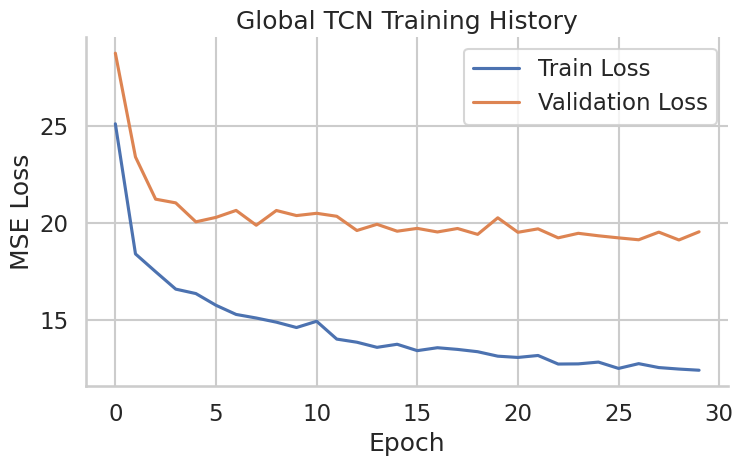

In [46]:
# ============================================================
# CELL 21.1: Plot TCN Training History
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(tcn_history.history["loss"], label="Train Loss")
plt.plot(tcn_history.history["val_loss"], label="Validation Loss")
plt.title("Global TCN Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# CELL 22: Global TCN Prediction and Drift Monitoring
# ============================================================

val_pred_tcn = tcn_model.predict(X_val_tcn, verbose=0).flatten()
test_pred_tcn = tcn_model.predict(X_test_tcn, verbose=0).flatten()

val_global_tcn = meta_val_tcn.copy()
val_global_tcn["daily_kWh"] = y_val_tcn
val_global_tcn["tcn_pred"] = val_pred_tcn
val_global_tcn["tcn_residual"] = val_global_tcn["daily_kWh"] - val_global_tcn["tcn_pred"]

test_global_tcn = meta_test_tcn.copy()
test_global_tcn["daily_kWh"] = y_test_tcn
test_global_tcn["tcn_pred"] = test_pred_tcn
test_global_tcn["tcn_residual"] = test_global_tcn["daily_kWh"] - test_global_tcn["tcn_pred"]

test_global_tcn = test_global_tcn.merge(
    test_global[["LCLid", "date", "carbon_intensity"]].drop_duplicates(),
    on=["LCLid", "date"], how="left"
)

tcn_baseline_by_house = {
    hid: g["tcn_residual"].dropna().values for hid, g in val_global_tcn.groupby("LCLid")
}

test_global_tcn = apply_drift_methods(test_global_tcn, "tcn_residual", "tcn", baseline_by_house=tcn_baseline_by_house)
tcn_metrics_all = compute_forecast_metrics(test_global_tcn, "daily_kWh", "tcn_pred", "TCN")
tcn_cusum_eval = evaluate_alerts(test_global_tcn, "tcn_cusum_alert", "tcn_residual", "TCN_CUSUM", baseline_by_house=tcn_baseline_by_house)
tcn_ewma_eval = evaluate_alerts(test_global_tcn, "tcn_ewma_alert", "tcn_residual", "TCN_EWMA", baseline_by_house=tcn_baseline_by_house)
carbon_tcn = carbon_impact_summary(test_global_tcn, "tcn_residual", "TCN")

In [51]:
import tqdm

# ============================================================
# CELL 23: STL + CUSUM + EWMA for All Selected Households
# ============================================================

def run_stl_for_household(df_home, test_start, val_start, period=7):
    df_home = df_home.sort_values("date").copy()
    baseline_df = df_home[df_home["date"] < test_start].copy()
    test_df = df_home[df_home["date"] >= test_start].copy()

    if len(baseline_df) < 90 or len(test_df) == 0:
        return None, None, None

    expected_vals = []
    residuals = []

    for i in range(len(df_home)):
        current_date = df_home.iloc[i]["date"]
        if current_date < test_start:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        past_df = df_home.iloc[:i].copy()
        if len(past_df) < 60:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        stl_df = stl_baseline(past_df, period=period, min_days=60)
        if stl_df is None:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        expected_today = stl_df["expected_kWh"].iloc[-1]
        observed_today = df_home.iloc[i]["daily_kWh"]

        expected_vals.append(expected_today)
        residuals.append(observed_today - expected_today)

    df_home["expected_test"] = expected_vals
    df_home["residual_test"] = residuals

    baseline_residuals = df_home.loc[
        (df_home["date"] >= val_start) & (df_home["date"] < test_start),
        "residual_test"
    ].dropna().values

    home_test = df_home[df_home["date"] >= test_start].copy()
    r = home_test["residual_test"].fillna(0).values

    cusum_pos, cusum_neg, cusum_alert, k, h, _, _ = cusum_drift(r, baseline_residuals=baseline_residuals)
    ewma_vals, ewma_alert, ewma_upper, ewma_lower, _, _ = ewma_drift(r, baseline_residuals=baseline_residuals)

    home_test["cusum_pos"] = cusum_pos
    home_test["cusum_neg"] = cusum_neg
    home_test["cusum_alert"] = cusum_alert
    home_test["cusum_k"] = k
    home_test["cusum_h"] = h
    home_test["ewma"] = ewma_vals
    home_test["ewma_alert"] = ewma_alert
    home_test["ewma_upper"] = ewma_upper
    home_test["ewma_lower"] = ewma_lower

    summary = pd.DataFrame({
        "LCLid": [df_home["LCLid"].iloc[0]],
        "stl_cusum_first_alert": [home_test.loc[home_test["cusum_alert"], "date"].min()],
        "stl_cusum_num_alerts": [int(home_test["cusum_alert"].sum())],
        "stl_ewma_first_alert": [home_test.loc[home_test["ewma_alert"], "date"].min()],
        "stl_ewma_num_alerts": [int(home_test["ewma_alert"].sum())]
    })

    return summary, home_test, baseline_residuals

stl_summaries = []
stl_test_all_list = []
stl_baseline_by_house = {}

for hid in tqdm.tqdm(selected_households, desc="Running STL for households"):
    home_df = merged2_sel[merged2_sel["LCLid"] == hid].copy()
    summary, home_test, baseline_res = run_stl_for_household(
        home_df,
        test_start,
        val_start,
        period=CONFIG["stl_period"]
    )
    if summary is not None:
        stl_summaries.append(summary)
        stl_test_all_list.append(home_test)
        if hid not in stl_baseline_by_house and baseline_res is not None:
            stl_baseline_by_house[hid] = baseline_res

if stl_test_all_list:
    stl_test_all = pd.concat(stl_test_all_list, ignore_index=True)
    stl_all_summaries = pd.concat(stl_summaries, ignore_index=True)

    stl_cusum_eval = evaluate_alerts(stl_test_all, "cusum_alert", "residual_test", "STL_CUSUM", baseline_by_house=stl_baseline_by_house)
    stl_ewma_eval = evaluate_alerts(stl_test_all, "ewma_alert", "residual_test", "STL_EWMA", baseline_by_house=stl_baseline_by_house)
    carbon_stl = carbon_impact_summary(stl_test_all, "residual_test", "STL")
else:
    print("No households had enough data for STL analysis.")
    stl_test_all = pd.DataFrame()
    stl_all_summaries = pd.DataFrame()
    stl_cusum_eval = pd.DataFrame()
    stl_ewma_eval = pd.DataFrame()
    carbon_stl = pd.DataFrame()

Running STL for households: 100%|██████████| 100/100 [04:16<00:00,  2.56s/it]


In [52]:
# ============================================================
# CELL 24: Consolidated Evaluation Tables
# ============================================================

forecast_metrics_all = pd.concat([
    xgb_metrics_all,
    rf_metrics_all,
    tcn_metrics_all
], ignore_index=True)

drift_eval_all = pd.concat([
    stl_cusum_eval, stl_ewma_eval,
    xgb_cusum_eval, xgb_ewma_eval,
    rf_cusum_eval, rf_ewma_eval,
    tcn_cusum_eval, tcn_ewma_eval
], ignore_index=True)

carbon_all = pd.concat([
    carbon_stl,
    carbon_xgb,
    carbon_rf,
    carbon_tcn
], ignore_index=True)

print("Forecast metrics shape:", forecast_metrics_all.shape)
print("Drift eval shape:", drift_eval_all.shape)
print("Carbon summary shape:", carbon_all.shape)

Forecast metrics shape: (270, 7)
Drift eval shape: (720, 8)
Carbon summary shape: (360, 4)


In [53]:
# ============================================================
# CELL 25: Selected Household Detailed Results
# ============================================================

xgb_one = test_global_xgb[test_global_xgb["LCLid"] == SELECTED_HOUSE].copy()
rf_one = test_global_rf[test_global_rf["LCLid"] == SELECTED_HOUSE].copy()
tcn_one = test_global_tcn[test_global_tcn["LCLid"] == SELECTED_HOUSE].copy()
stl_one = stl_details.get(SELECTED_HOUSE, pd.DataFrame()).copy()

xgb_metrics_one = regression_metrics(xgb_one["daily_kWh"], xgb_one["xgb_pred"]) if len(xgb_one) else None
rf_metrics_one = regression_metrics(rf_one["daily_kWh"], rf_one["rf_pred"]) if len(rf_one) else None
tcn_metrics_one = regression_metrics(tcn_one["daily_kWh"], tcn_one["tcn_pred"]) if len(tcn_one) else None

selected_house_summary = pd.DataFrame({
    "LCLid": [SELECTED_HOUSE],
    "xgb_mae": [xgb_metrics_one["mae"] if xgb_metrics_one else np.nan],
    "xgb_rmse": [xgb_metrics_one["rmse"] if xgb_metrics_one else np.nan],
    "xgb_smape": [xgb_metrics_one["smape"] if xgb_metrics_one else np.nan],
    "xgb_r2": [xgb_metrics_one["r2"] if xgb_metrics_one else np.nan],
    "rf_mae": [rf_metrics_one["mae"] if rf_metrics_one else np.nan],
    "rf_rmse": [rf_metrics_one["rmse"] if rf_metrics_one else np.nan],
    "rf_smape": [rf_metrics_one["smape"] if rf_metrics_one else np.nan],
    "rf_r2": [rf_metrics_one["r2"] if rf_metrics_one else np.nan],
    "tcn_mae": [tcn_metrics_one["mae"] if tcn_metrics_one else np.nan],
    "tcn_rmse": [tcn_metrics_one["rmse"] if tcn_metrics_one else np.nan],
    "tcn_smape": [tcn_metrics_one["smape"] if tcn_metrics_one else np.nan],
    "tcn_r2": [tcn_metrics_one["r2"] if tcn_metrics_one else np.nan],
    "stl_cusum_alerts": [int(stl_one["cusum_alert"].sum()) if len(stl_one) else 0],
    "stl_ewma_alerts": [int(stl_one["ewma_alert"].sum()) if len(stl_one) else 0],
    "xgb_cusum_alerts": [int(xgb_one["xgb_cusum_alert"].sum()) if len(xgb_one) else 0],
    "rf_cusum_alerts": [int(rf_one["rf_cusum_alert"].sum()) if len(rf_one) else 0],
    "tcn_cusum_alerts": [int(tcn_one["tcn_cusum_alert"].sum()) if len(tcn_one) else 0]
})

selected_house_summary

,LCLid,xgb_mae,xgb_rmse,xgb_smape,xgb_r2,rf_mae,rf_rmse,rf_smape,rf_r2,tcn_mae,tcn_rmse,tcn_smape,tcn_r2,stl_cusum_alerts,stl_ewma_alerts,xgb_cusum_alerts,rf_cusum_alerts,tcn_cusum_alerts
0,MAC000006,0.377,0.573,12.854,-0.137,0.384,0.572,13.085,-0.131,0.444,0.656,14.560,-0.487,0,0,1,42,1


In [54]:
# ============================================================
# CELL 26.1: Model-Level Forecast Summary
# ============================================================

model_summary = (
    forecast_metrics_all.groupby("model")
    .agg(mean_mae=("mae", "mean"),
         mean_rmse=("rmse", "mean"),
         mean_mape=("mape", "mean"),
         mean_smape=("smape", "mean"),
         mean_r2=("r2", "mean"))
    .reset_index()
    .sort_values("mean_mae")
)
model_summary

,model,mean_mae,mean_rmse,mean_mape,mean_smape,mean_r2
2,XGBoost,2.340,3.293,"998,961.316",23.110,0.074
0,RandomForest,2.385,3.318,"766,103.306",23.417,0.089
1,TCN,2.431,3.379,"1,079,393.041",24.277,-0.142


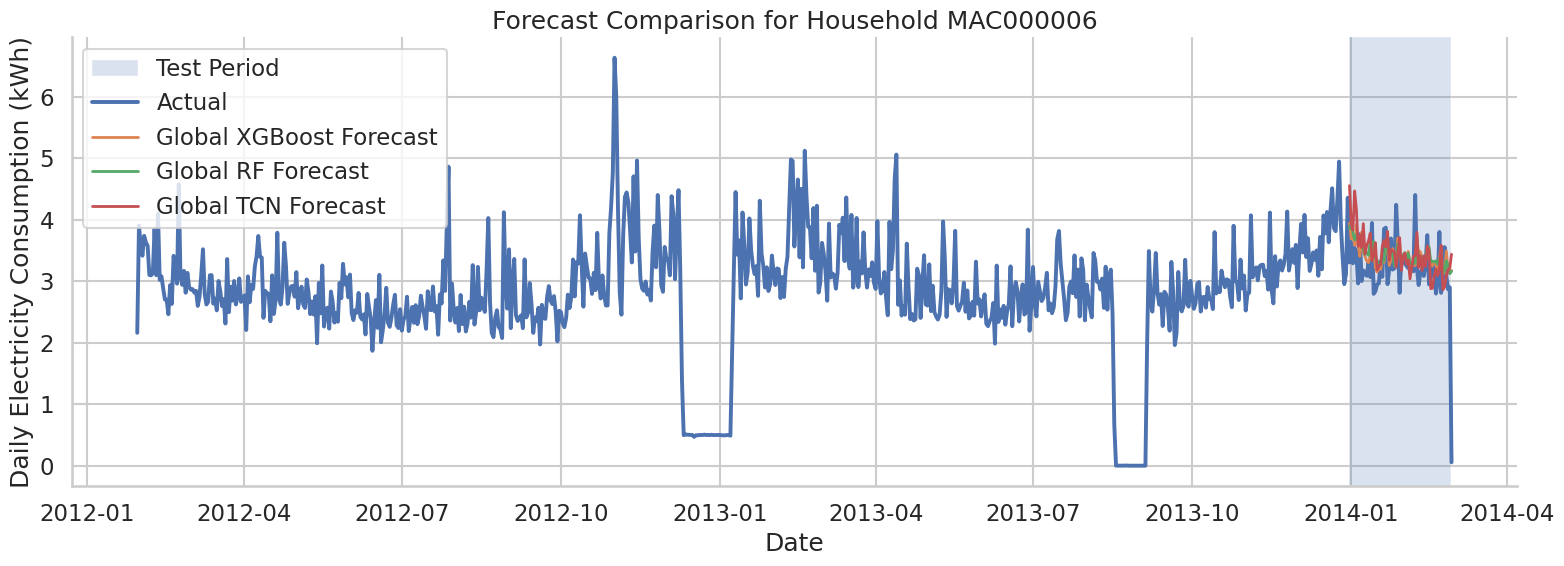

In [55]:
# ============================================================
# CELL 27.1: Forecast Comparison Plot for Selected Household
# ============================================================

raw_one_house = merged2_sel[merged2_sel["LCLid"] == SELECTED_HOUSE].copy().sort_values("date")

plt.figure(figsize=(16, 6))
plt.axvspan(test_start, raw_one_house["date"].max(), alpha=0.2, label="Test Period")
plt.plot(raw_one_house["date"], raw_one_house["daily_kWh"], label="Actual", linewidth=2.8)

if len(stl_one):
    plt.plot(stl_one["date"], stl_one["expected_test"], label="STL Expected", linewidth=2)
if len(xgb_one):
    plt.plot(xgb_one["date"], xgb_one["xgb_pred"], label="Global XGBoost Forecast", linewidth=2)
if len(rf_one):
    plt.plot(rf_one["date"], rf_one["rf_pred"], label="Global RF Forecast", linewidth=2)
if len(tcn_one):
    plt.plot(tcn_one["date"], tcn_one["tcn_pred"], label="Global TCN Forecast", linewidth=2)

plt.title(f"Forecast Comparison for Household {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("Daily Electricity Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# CELL 27.2: STL Drift Plot for Selected Household
# ============================================================

if len(stl_one):
    plt.figure(figsize=(16, 6))
    plt.axvspan(test_start, stl_one["date"].max(), alpha=0.2, label="Test Period")
    plt.plot(stl_one["date"], np.abs(stl_one["cusum_neg"]), label="CUSUM Magnitude", linewidth=2.2)
    plt.plot(stl_one["date"], np.abs(stl_one["ewma"]), label="EWMA Magnitude", linewidth=2.2)
    if "cusum_h" in stl_one.columns:
        plt.axhline(stl_one["cusum_h"].iloc[0], linestyle="--", label="CUSUM Threshold")
    if "ewma_upper" in stl_one.columns and pd.notna(stl_one["ewma_upper"].iloc[0]):
        plt.axhline(abs(stl_one["ewma_upper"].iloc[0]), linestyle=":", label="EWMA Threshold")
    plt.title(f"STL Drift Detection for Household {SELECTED_HOUSE}")
    plt.xlabel("Date")
    plt.ylabel("Drift Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

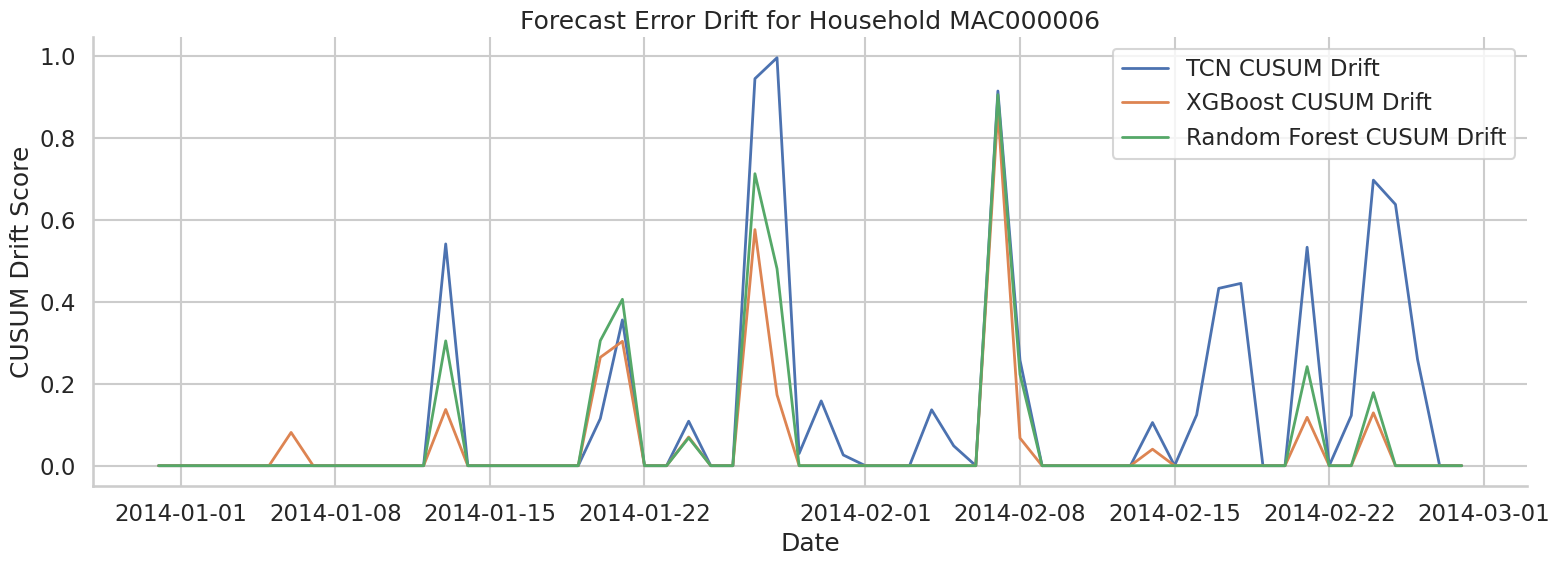

In [58]:
# ============================================================
# CELL 27.3: Forecast Error Drift Plot for Selected Household
# ============================================================

plt.figure(figsize=(16, 6))
if len(tcn_one):
    plt.plot(tcn_one["date"], np.abs(tcn_one["tcn_cusum_pos"]), label="TCN CUSUM Drift", linewidth=2)
if len(xgb_one):
    plt.plot(xgb_one["date"], np.abs(xgb_one["xgb_cusum_pos"]), label="XGBoost CUSUM Drift", linewidth=2)
if len(rf_one):
    plt.plot(rf_one["date"], np.abs(rf_one["rf_cusum_pos"]), label="Random Forest CUSUM Drift", linewidth=2)

plt.title(f"Forecast Error Drift for Household {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("CUSUM Drift Score")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# CELL 28: Multi-Household Comparison Table
# ============================================================

compare_households = selected_households[:CONFIG["max_compare_houses"]]

# alert count helper
def alert_count_by_house(df_, alert_col):
    return (
        df_.groupby("LCLid")[alert_col]
        .sum()
        .reset_index()
        .rename(columns={alert_col: f"{alert_col}_count"})
    )

comparison = pd.DataFrame({"LCLid": compare_households})

for df_, col in [
    (stl_test_all, "cusum_alert"),
    (stl_test_all, "ewma_alert"),
    (test_global_xgb, "xgb_cusum_alert"),
    (test_global_xgb, "xgb_ewma_alert"),
    (test_global_rf, "rf_cusum_alert"),
    (test_global_rf, "rf_ewma_alert"),
    (test_global_tcn, "tcn_cusum_alert"),
    (test_global_tcn, "tcn_ewma_alert")
]:
    comparison = comparison.merge(alert_count_by_house(df_, col), on="LCLid", how="left")

metric_wide = forecast_metrics_all.pivot(index="LCLid", columns="model", values=["mae", "rmse", "smape", "r2"])
metric_wide.columns = [f"{a}_{b}" for a, b in metric_wide.columns]
metric_wide = metric_wide.reset_index()
comparison = comparison.merge(metric_wide, on="LCLid", how="left")

carbon_wide = carbon_all.pivot(index="LCLid", columns="model", values="excess_carbon_g").reset_index()
carbon_wide.columns = ["LCLid" if c == "LCLid" else f"carbon_{c}" for c in carbon_wide.columns]
comparison = comparison.merge(carbon_wide, on="LCLid", how="left")

comparison.fillna(0, inplace=True)
comparison

,LCLid,cusum_alert_count,ewma_alert_count,xgb_cusum_alert_count,xgb_ewma_alert_count,rf_cusum_alert_count,rf_ewma_alert_count,tcn_cusum_alert_count,tcn_ewma_alert_count,mae_RandomForest,mae_TCN,mae_XGBoost,rmse_RandomForest,rmse_TCN,rmse_XGBoost,smape_RandomForest,smape_TCN,smape_XGBoost,r2_RandomForest,r2_TCN,r2_XGBoost,carbon_RandomForest,carbon_STL,carbon_TCN,carbon_XGBoost
0,MAC000002,0.000,0.000,1.000,0.000,22.000,10.000,1.000,1.000,2.794,2.951,2.838,3.912,4.067,3.930,18.344,19.182,18.583,-0.035,-0.119,-0.045,"38,971.932","50,529.931","44,944.265","41,115.379"
1,MAC000003,0.000,0.000,0.000,0.000,23.000,2.000,0.000,0.000,7.504,6.984,6.139,8.656,8.803,8.195,42.864,40.113,35.006,0.305,0.281,0.377,"105,406.149","102,731.334","103,998.031","87,747.035"
2,MAC000004,0.000,0.000,1.000,1.000,1.000,1.000,32.000,12.000,0.116,0.371,0.170,0.239,0.496,0.277,7.844,19.997,10.763,-0.130,-3.867,-0.511,455.892,"1,542.427",423.060,549.907
3,MAC000006,0.000,0.000,1.000,2.000,42.000,7.000,1.000,7.000,0.384,0.444,0.377,0.572,0.656,0.573,13.085,14.560,12.854,-0.131,-0.487,-0.137,"2,270.689","5,127.038","2,883.148","2,497.604"
4,MAC000007,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.585,3.282,3.350,4.766,4.747,4.734,31.026,28.450,29.285,-0.155,-0.146,-0.140,"30,323.048","49,883.945","39,277.442","35,164.643"
5,MAC000008,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,MAC000009,0.000,0.000,1.000,1.000,1.000,1.000,1.000,2.000,1.143,1.174,1.070,1.657,1.704,1.618,13.565,13.823,12.791,0.113,0.063,0.155,"12,113.858","16,809.470","12,780.142","11,173.569"
7,MAC000010,0.000,0.000,9.000,1.000,50.000,10.000,0.000,1.000,4.107,4.279,4.162,5.514,5.665,5.571,15.591,16.188,15.819,0.361,0.325,0.347,"38,480.802","56,412.331","56,318.068","52,152.093"
8,MAC000011,0.000,0.000,0.000,2.000,1.000,6.000,1.000,3.000,2.430,2.617,2.432,3.391,3.650,3.404,19.503,20.689,19.539,-0.027,-0.190,-0.034,"29,486.844","34,105.953","32,056.390","29,887.872"
9,MAC000012,0.000,0.000,34.000,0.000,0.000,0.000,43.000,15.000,0.159,0.439,0.136,0.281,0.548,0.287,14.610,33.301,12.537,-0.585,-5.041,-0.650,847.640,"1,577.643",433.188,967.653


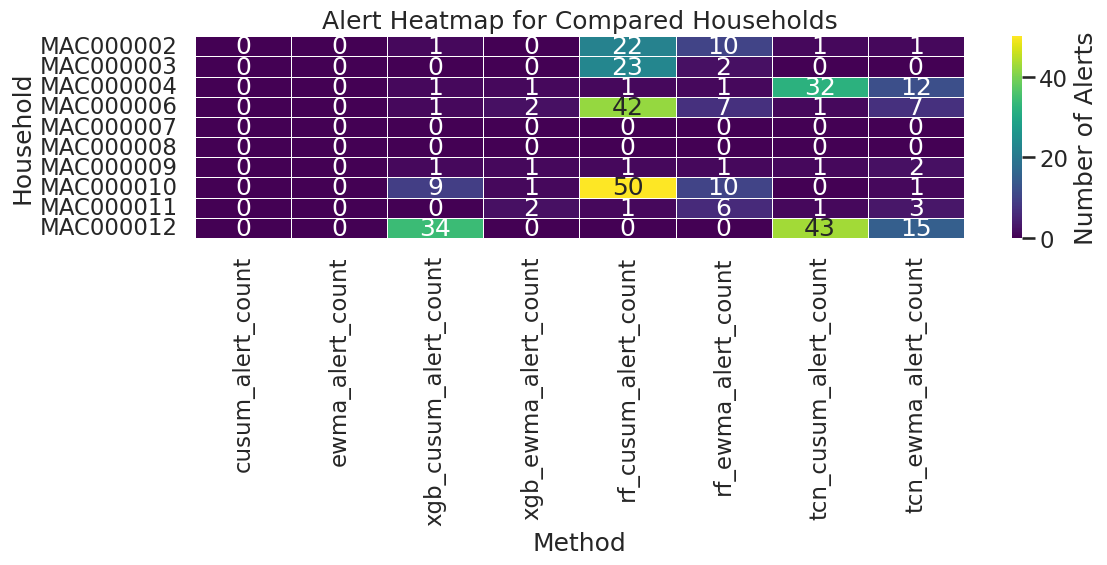

In [60]:
# ============================================================
# CELL 28.1: Alert Heatmap for Compared Households
# ============================================================

heat_cols = [
    "cusum_alert_count", "ewma_alert_count",
    "xgb_cusum_alert_count", "xgb_ewma_alert_count",
    "rf_cusum_alert_count", "rf_ewma_alert_count",
    "tcn_cusum_alert_count", "tcn_ewma_alert_count"
]

heatmap_df = comparison[["LCLid"] + heat_cols].set_index("LCLid")

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="viridis", linewidths=0.5,
            cbar_kws={"label": "Number of Alerts"})
plt.title("Alert Heatmap for Compared Households")
plt.xlabel("Method")
plt.ylabel("Household")
plt.tight_layout()
plt.show()

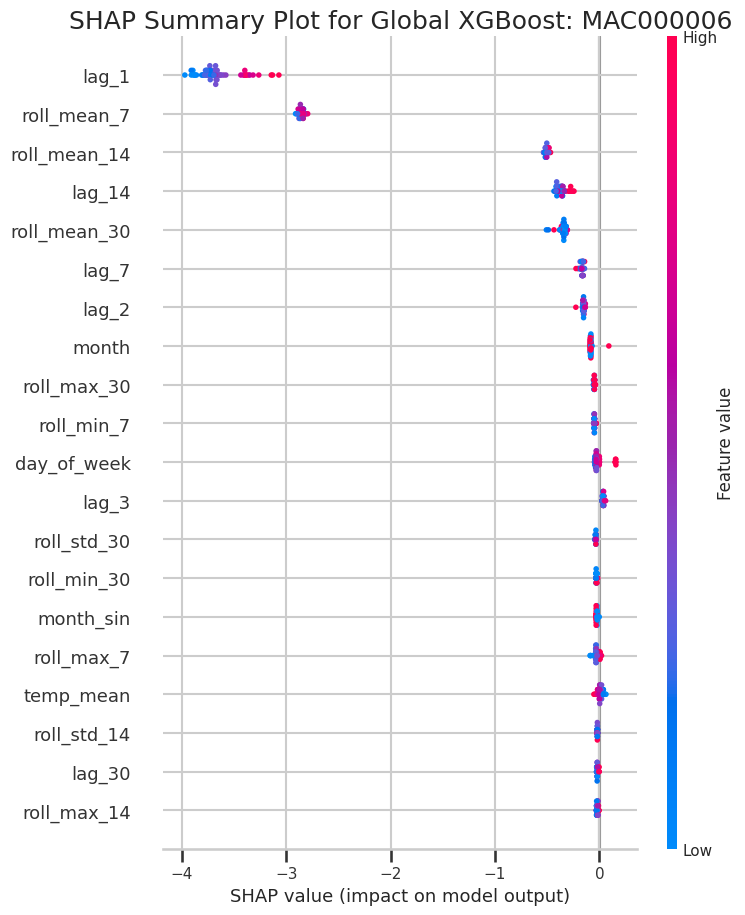

In [61]:
# ============================================================
# CELL 29.1: SHAP for Global XGBoost on Selected Household
# ============================================================

X_test_xgb_shap = test_global[test_global["LCLid"] == SELECTED_HOUSE][feature_cols].copy()

if len(X_test_xgb_shap) > 0:
    explainer = shap.Explainer(global_xgb)
    shap_values = explainer(X_test_xgb_shap)
    shap.summary_plot(shap_values, X_test_xgb_shap, show=False)
    plt.title(f"SHAP Summary Plot for Global XGBoost: {SELECTED_HOUSE}")
    plt.tight_layout()
    plt.show()

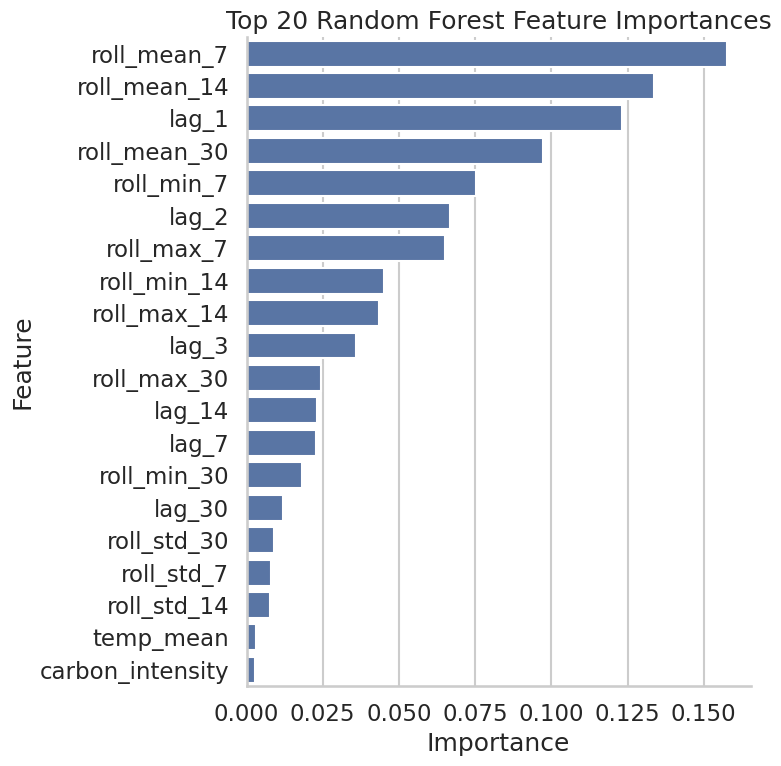

,feature,importance
26,roll_mean_7,0.158
30,roll_mean_14,0.134
20,lag_1,0.123
34,roll_mean_30,0.097
28,roll_min_7,0.075
21,lag_2,0.067
29,roll_max_7,0.065
32,roll_min_14,0.045
33,roll_max_14,0.043
22,lag_3,0.036


In [62]:
# ============================================================
# CELL 29.2: Random Forest Feature Importance
# ============================================================

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": global_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=rf_importance.head(20), x="importance", y="feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

rf_importance.head(20)

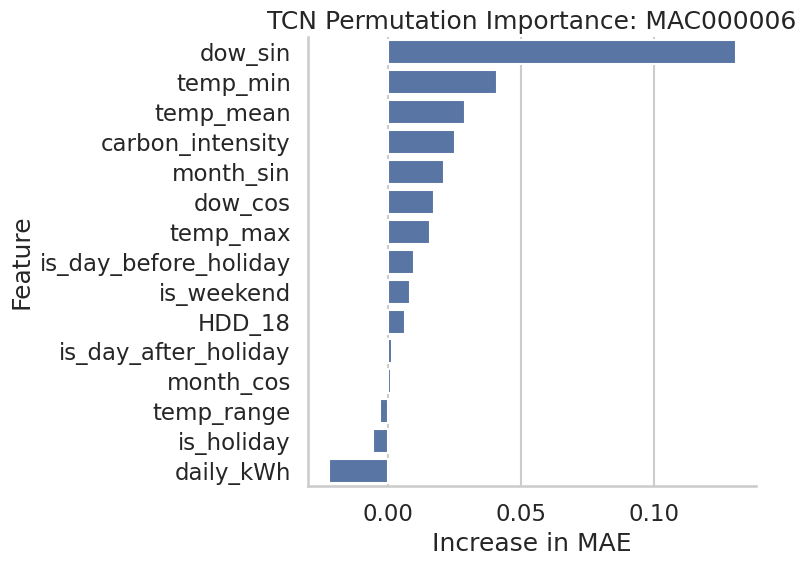

In [63]:
# ============================================================
# CELL 29.3: TCN Permutation Importance (Selected Household)
# ============================================================

def tcn_permutation_importance_selected_house(model, X_house, y_house, feature_names):
    baseline_pred = model.predict(X_house, verbose=0).flatten()
    baseline_error = mean_absolute_error(y_house, baseline_pred)

    importances = []
    for f_idx, f_name in enumerate(feature_names):
        X_perm = X_house.copy()
        np.random.shuffle(X_perm[:, :, f_idx])
        pred = model.predict(X_perm, verbose=0).flatten()
        err = mean_absolute_error(y_house, pred)
        importances.append(err - baseline_error)

    return pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

selected_house_tcn_idx = meta_test_tcn[meta_test_tcn["LCLid"] == SELECTED_HOUSE].index
if len(selected_house_tcn_idx) > 0:
    X_house_tcn = X_test_tcn[selected_house_tcn_idx]
    y_house_tcn = y_test_tcn[selected_house_tcn_idx]
    perm_df = tcn_permutation_importance_selected_house(tcn_model, X_house_tcn, y_house_tcn, seq_feature_cols)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=perm_df.head(15), x="importance", y="feature")
    plt.title(f"TCN Permutation Importance: {SELECTED_HOUSE}")
    plt.xlabel("Increase in MAE")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [65]:
# ============================================================
# CELL 30: Export Outputs
# ============================================================

outdir = CONFIG["output_dir"]

carbon_model_summary = (
    carbon_all.groupby("model")
    .agg(total_excess_carbon_g=("excess_carbon_g", "sum"))
    .reset_index()
)

selected_house_summary.to_csv(f"{outdir}/selected_house_summary.csv", index=False)
comparison.to_csv(f"{outdir}/comparison_summary.csv", index=False)
forecast_metrics_all.to_csv(f"{outdir}/forecast_metrics_all.csv", index=False)
drift_eval_all.to_csv(f"{outdir}/drift_eval_all.csv", index=False)
carbon_all.to_csv(f"{outdir}/carbon_all.csv", index=False)
model_summary.to_csv(f"{outdir}/model_summary.csv", index=False)
carbon_model_summary.to_csv(f"{outdir}/carbon_model_summary.csv", index=False)
xgb_cv_results.to_csv(f"{outdir}/xgb_cv_results.csv", index=False)
rf_cv_results.to_csv(f"{outdir}/rf_cv_results.csv", index=False)

test_global_xgb.to_csv(f"{outdir}/xgb_test_residuals.csv", index=False)
test_global_rf.to_csv(f"{outdir}/rf_test_residuals.csv", index=False)
test_global_tcn.to_csv(f"{outdir}/tcn_test_residuals.csv", index=False)
stl_test_all.to_csv(f"{outdir}/stl_test_residuals.csv", index=False)

xgb_one.to_csv(f"{outdir}/{SELECTED_HOUSE}_xgb_detail.csv", index=False)
rf_one.to_csv(f"{outdir}/{SELECTED_HOUSE}_rf_detail.csv", index=False)
tcn_one.to_csv(f"{outdir}/{SELECTED_HOUSE}_tcn_detail.csv", index=False)
if len(stl_one):
    stl_one.to_csv(f"{outdir}/{SELECTED_HOUSE}_stl_detail.csv", index=False)

print("All output files exported to:", outdir)


All output files exported to: outputs_global


In [67]:
# ============================================================
# CELL 31: Save Streamlit App
# ============================================================

streamlit_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Energy Drift Dashboard", layout="wide")
st.title("Household Energy Drift Detection Dashboard")

OUTDIR = "outputs_global"

comparison = pd.read_csv(f"{OUTDIR}/comparison_summary.csv")
forecast_metrics_all = pd.read_csv(f"{OUTDIR}/forecast_metrics_all.csv")
carbon_all = pd.read_csv(f"{OUTDIR}/carbon_all.csv")
model_summary = pd.read_csv(f"{OUTDIR}/model_summary.csv")
carbon_model_summary = pd.read_csv(f"{OUTDIR}/carbon_model_summary.csv")

households = sorted(comparison["LCLid"].dropna().unique().tolist())

st.sidebar.header("Controls")
selected_house = st.sidebar.selectbox("Select one household", households)
compare_houses = st.sidebar.multiselect("Select households to compare", households, default=households[:3])

st.subheader("Model Summary")
st.dataframe(model_summary)

st.subheader("Carbon Summary by Model")
st.dataframe(carbon_model_summary)

st.subheader(f"Detailed View: {selected_house}")

col1, col2 = st.columns(2)
with col1:
    st.write("Forecast Metrics")
    st.dataframe(forecast_metrics_all[forecast_metrics_all["LCLid"] == selected_house])
with col2:
    st.write("Carbon Impact")
    st.dataframe(carbon_all[carbon_all["LCLid"] == selected_house])

# load detail files
fig, ax = plt.subplots(figsize=(10, 4))
loaded_any = False

try:
    stl_df = pd.read_csv(f"{OUTDIR}/{selected_house}_stl_detail.csv")
    stl_df["date"] = pd.to_datetime(stl_df["date"])
    ax.plot(stl_df["date"], stl_df["daily_kWh"], label="Actual")
    if "expected_test" in stl_df.columns:
        ax.plot(stl_df["date"], stl_df["expected_test"], label="STL Expected")
    loaded_any = True
except:
    pass

try:
    xgb_df = pd.read_csv(f"{OUTDIR}/{selected_house}_xgb_detail.csv")
    xgb_df["date"] = pd.to_datetime(xgb_df["date"])
    if "xgb_pred" in xgb_df.columns:
        ax.plot(xgb_df["date"], xgb_df["xgb_pred"], label="XGBoost")
    loaded_any = True
except:
    pass

try:
    rf_df = pd.read_csv(f"{OUTDIR}/{selected_house}_rf_detail.csv")
    rf_df["date"] = pd.to_datetime(rf_df["date"])
    if "rf_pred" in rf_df.columns:
        ax.plot(rf_df["date"], rf_df["rf_pred"], label="Random Forest")
    loaded_any = True
except:
    pass
'''
print("Streamlit app saved to:", f"{CONFIG['streamlit_dir']}/app.py")

Streamlit app saved to: streamlit_app/app.py


In [68]:
# ============================================================
# CELL 31.1: How to Run Streamlit in Colab
# ============================================================

print("Run these commands in Colab terminal or notebook shell if needed:")
print("\ncd streamlit_app")
print("streamlit run app.py --server.port 8501")

Run these commands in Colab terminal or notebook shell if needed:

cd streamlit_app
streamlit run app.py --server.port 8501


In [69]:
# ============================================================
# CELL 32: Final Summary Prints
# ============================================================

print("\n========== MODEL SUMMARY ==========")
print(model_summary)

print("\n========== CARBON SUMMARY ==========")
print(carbon_model_summary)

print("\n========== SELECTED HOUSE SUMMARY ==========")
print(selected_house_summary)

print("\n========== COMPARED HOUSEHOLDS ==========")
print(comparison[["LCLid"]].head(CONFIG["max_compare_houses"]))


========== MODEL SUMMARY ==========
          model  mean_mae  mean_rmse     mean_mape  mean_smape  mean_r2
2       XGBoost     2.340      3.293   998,961.316      23.110    0.074
0  RandomForest     2.385      3.318   766,103.306      23.417    0.089
1           TCN     2.431      3.379 1,079,393.041      24.277   -0.142

========== CARBON SUMMARY ==========
          model  total_excess_carbon_g
0  RandomForest          2,503,290.849
1           STL          3,206,682.112
2           TCN          2,906,363.493
3       XGBoost          2,691,255.303

========== SELECTED HOUSE SUMMARY ==========
       LCLid  xgb_mae  xgb_rmse  xgb_smape  xgb_r2  rf_mae  rf_rmse  rf_smape  \
0  MAC000006    0.377     0.573     12.854  -0.137   0.384    0.572    13.085   

   rf_r2  tcn_mae  tcn_rmse  tcn_smape  tcn_r2  stl_cusum_alerts  \
0 -0.131    0.444     0.656     14.560  -0.487                 0   

   stl_ewma_alerts  xgb_cusum_alerts  rf_cusum_alerts  tcn_cusum_alerts  
0                0    